In [22]:
import pandas as pd
from pathlib import Path
import sys
import inspect
import importlib
import numpy as np

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from src.profile_trainer import run_profile_training_experiment

In [28]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\15_min\df_BU_TotActPwr_Academy.parquet"
df_imputed = pd.read_parquet(path)


In [29]:


target_col = "BU_TotActPwr_Academy"

feature_cols = [c for c in df_imputed.columns if c != target_col]

results_df, horizon_results = run_profile_training_experiment(
    df=df_imputed,
    target_col=target_col,
    feature_cols=feature_cols,
    dataset_name="15min_profile_dataset",
    output_dir="artifacts/profile_forecasting",
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    selected_models=["multi_ridge", "multi_random_forest", "multi_xgboost"],
    drop_feature_nan=False,
)

results_df

Training multi_ridge for day-ahead profile forecasting: BU_TotActPwr_Academy
Training multi_random_forest for day-ahead profile forecasting: BU_TotActPwr_Academy
Training multi_xgboost for day-ahead profile forecasting: BU_TotActPwr_Academy


,timestamp,task_type,dataset_name,target,model_name,model_params,n_features,n_horizons,n_train_days,n_val_days,...,val_MAPE,val_sMAPE,val_R2,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2,prediction_path,horizon_metrics_path
0,2026-04-01 15:11:45,day_ahead_profile_forecasting,15min_profile_dataset,BU_TotActPwr_Academy,multi_ridge,"{""estimator__alpha"": 1.0, ""estimator__copy_X"":...",38,96,77,16,...,29.302867,24.573377,0.696291,2.108500,3.362267,22.691000,21.939780,0.789716,artifacts\profile_forecasting\predictions\mult...,artifacts\profile_forecasting\horizon_metrics\...
1,2026-04-01 15:11:46,day_ahead_profile_forecasting,15min_profile_dataset,BU_TotActPwr_Academy,multi_random_forest,"{""estimator__bootstrap"": true, ""estimator__ccp...",38,96,77,16,...,25.541352,22.568083,0.708349,2.258453,3.844697,20.709556,21.124733,0.725042,artifacts\profile_forecasting\predictions\mult...,artifacts\profile_forecasting\horizon_metrics\...
2,2026-04-01 15:12:47,day_ahead_profile_forecasting,15min_profile_dataset,BU_TotActPwr_Academy,multi_xgboost,"{""estimator__objective"": ""reg:squarederror"", ""...",38,96,77,16,...,23.668712,21.722331,0.735772,2.194764,3.709358,20.217784,20.738223,0.744059,artifacts\profile_forecasting\predictions\mult...,artifacts\profile_forecasting\horizon_metrics\...


In [30]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_profile_day(prediction_csv_path, row_idx=0, title=None):
    df = pd.read_csv(prediction_csv_path, index_col=0, parse_dates=True)

    true_cols = [c for c in df.columns if c.endswith("_true")]
    pred_cols = [c for c in df.columns if c.endswith("_pred")]

    true_vals = df.iloc[row_idx][true_cols].values.astype(float)
    pred_vals = df.iloc[row_idx][pred_cols].values.astype(float)

    issue_time = df.index[row_idx]

    plt.figure(figsize=(14, 5))
    plt.plot(true_vals, label="Actual")
    plt.plot(pred_vals, label="Predicted")
    plt.xlabel("15-minute step of next day")
    plt.ylabel("Load / Power")
    plt.title(title or f"Day-ahead profile forecast\nIssue time: {issue_time}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

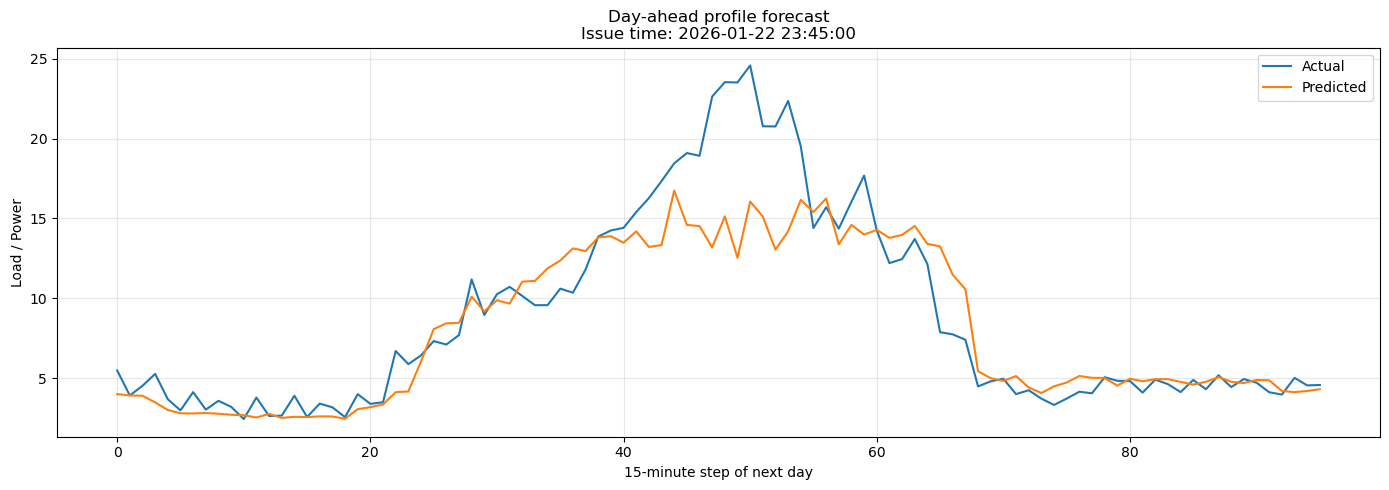

In [36]:
prediction_csv_path = r"C:\Data_analysis\Thesis\JupyterNotebooks\artifacts\profile_forecasting\predictions\multi_random_forest_BU_TotActPwr_Academy_profile_predictions.csv"
plot_profile_day(prediction_csv_path, row_idx=0)

In [37]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_multiple_profile_days(prediction_csv_path, row_indices=(0, 1, 2)):
    df = pd.read_csv(prediction_csv_path, index_col=0, parse_dates=True)

    true_cols = [c for c in df.columns if c.endswith("_true")]
    pred_cols = [c for c in df.columns if c.endswith("_pred")]

    for row_idx in row_indices:
        true_vals = df.iloc[row_idx][true_cols].values.astype(float)
        pred_vals = df.iloc[row_idx][pred_cols].values.astype(float)
        issue_time = df.index[row_idx]

        plt.figure(figsize=(14, 5))
        plt.plot(true_vals, label="Actual")
        plt.plot(pred_vals, label="Predicted")
        plt.xlabel("15-minute step of next day")
        plt.ylabel("Load / Power")
        plt.title(f"Day-ahead profile forecast\nIssue time: {issue_time}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

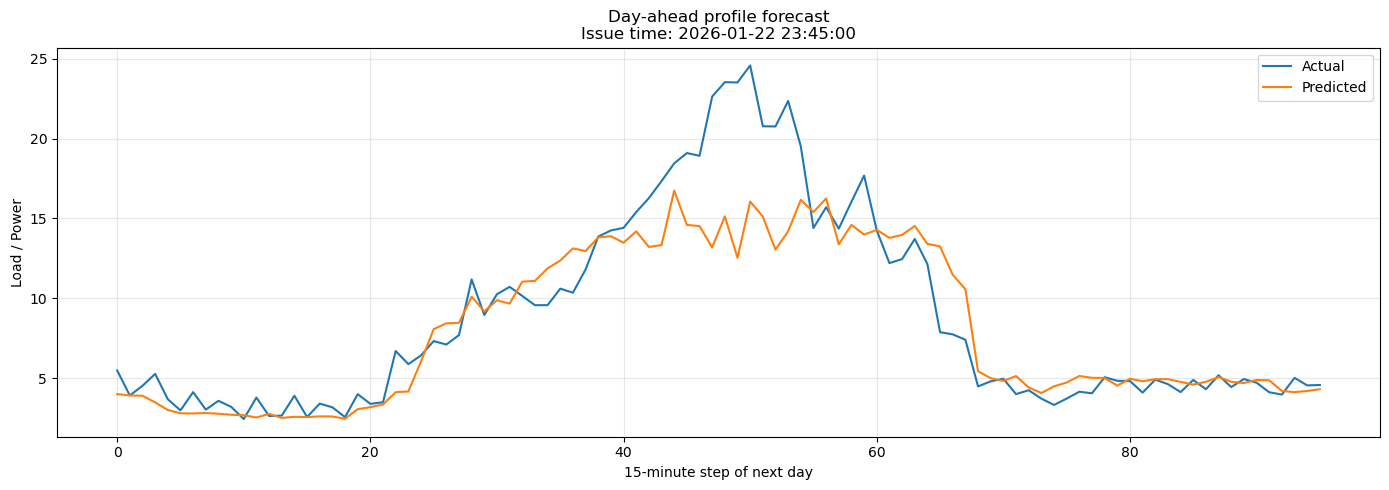

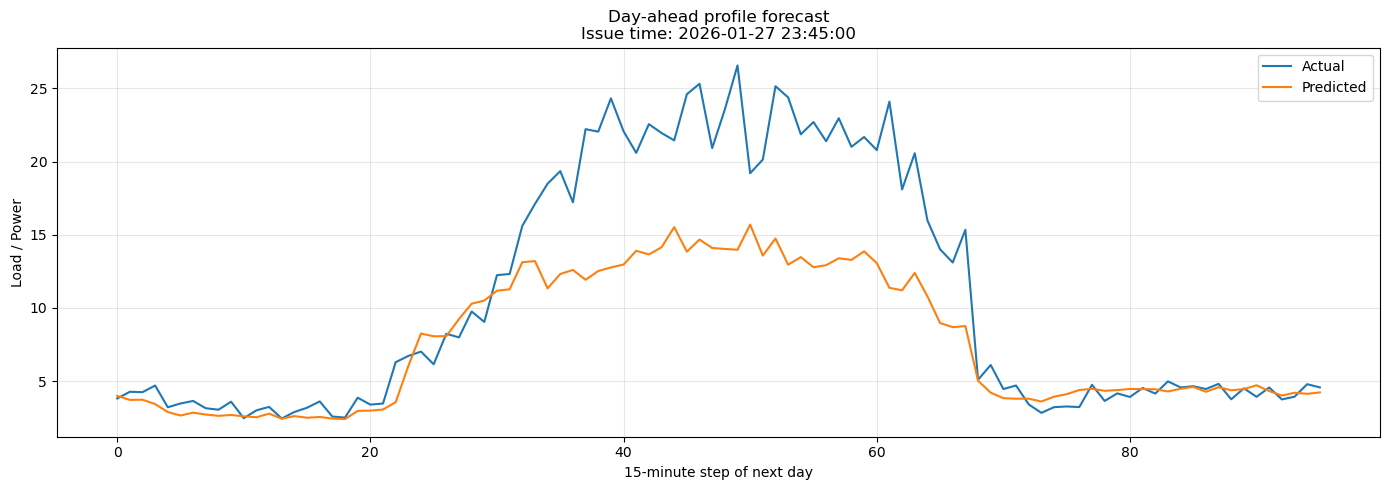

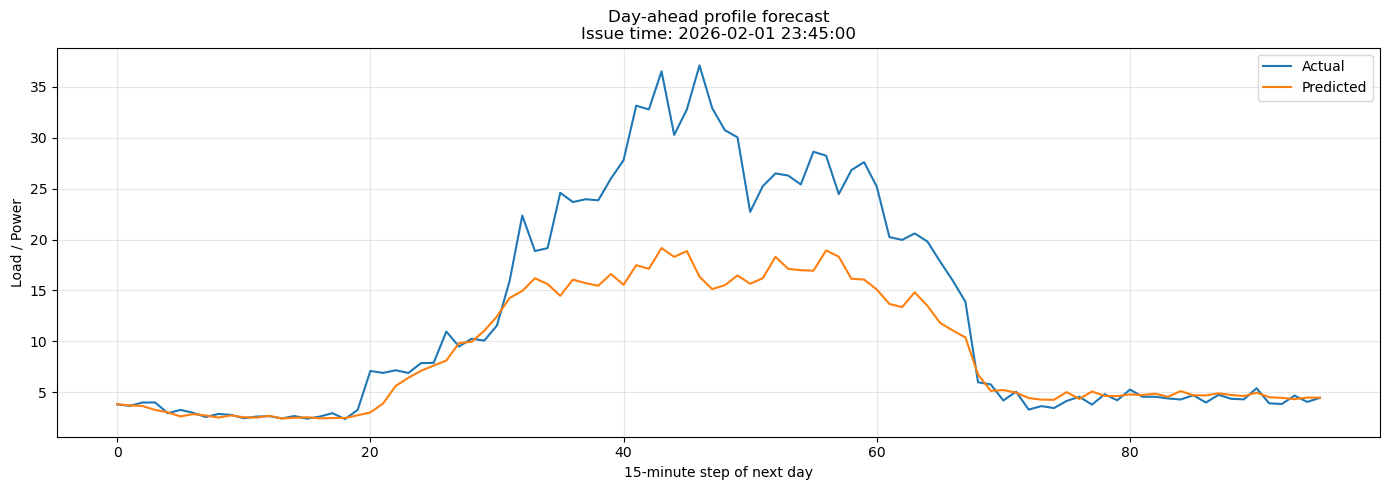

In [38]:
plot_multiple_profile_days(
    prediction_csv_path,
    row_indices=(0, 5, 10)
)

In [34]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_average_profile(prediction_csv_path, title="Average day-ahead profile"):
    df = pd.read_csv(prediction_csv_path, index_col=0, parse_dates=True)

    true_cols = [c for c in df.columns if c.endswith("_true")]
    pred_cols = [c for c in df.columns if c.endswith("_pred")]

    true_mean = df[true_cols].mean(axis=0).values.astype(float)
    pred_mean = df[pred_cols].mean(axis=0).values.astype(float)

    plt.figure(figsize=(14, 5))
    plt.plot(true_mean, label="Average Actual")
    plt.plot(pred_mean, label="Average Predicted")
    plt.xlabel("15-minute step of next day")
    plt.ylabel("Load / Power")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

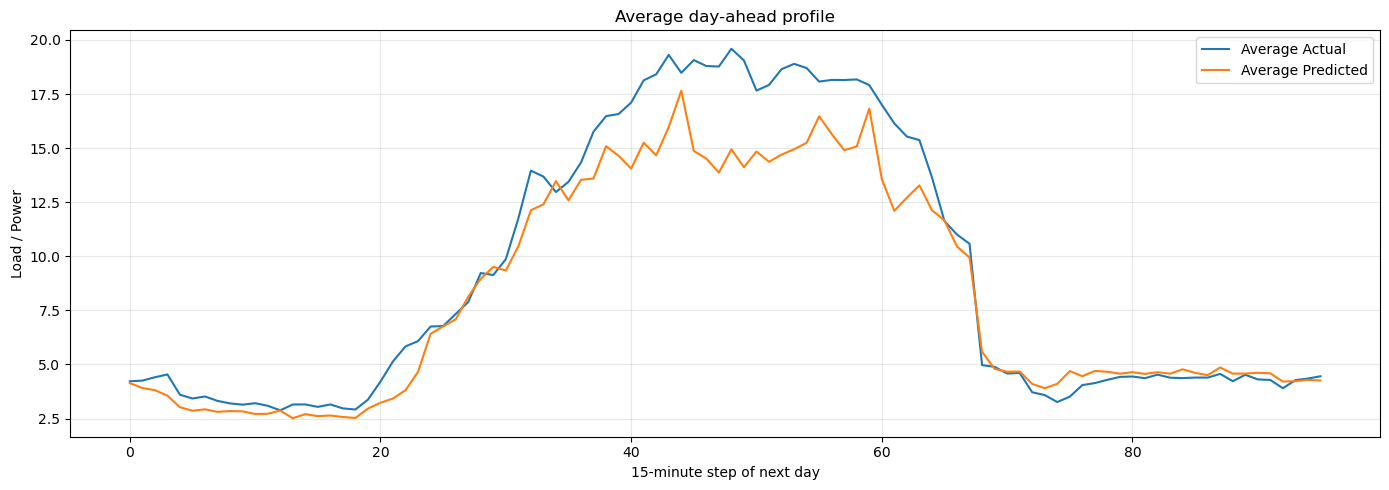

In [35]:
plot_average_profile(prediction_csv_path)